In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [29]:
df=pd.read_csv('fordgobike-tripdataFor201902.csv')
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [30]:
df.shape

(183416, 16)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [32]:
df['user_type']=df['user_type'].astype('category')
df['member_gender']=df['member_gender'].astype('category')

df['start_station_id']=df['start_station_id'].astype('str')
df['end_station_id']=df['end_station_id'].astype('str')

In [33]:
# df['start_time']=pd.to_datetime(df['start_time'])
# df['end_time']=pd.to_datetime(df['end_time'])

In [34]:
df.duplicated().sum()

np.int64(4)

In [35]:
df=df.drop_duplicates()

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

Fixing missing values
***********************************

In [38]:
# mode1=df['member_gender'].mode()
# # df['member_gender'].fillna(mode1,inplace=True)
# df.fillna({'member_gender': mode1}, inplace=True)
df["member_gender"] = df["member_gender"].cat.add_categories("Unknown")
df["member_gender"].fillna("Unknown", inplace=True)

0            Male
1         Unknown
2            Male
3           Other
4            Male
           ...   
183407       Male
183408       Male
183409       Male
183410       Male
183411       Male
Name: member_gender, Length: 183412, dtype: category
Categories (4, str): ['Female', 'Male', 'Other', 'Unknown']

In [39]:
median1=df['member_birth_year'].median()
df['member_birth_year'].fillna(median1,inplace=True)


0         1984.0
1         1987.0
2         1972.0
3         1989.0
4         1974.0
           ...  
183407    1996.0
183408    1984.0
183409    1990.0
183410    1988.0
183411    1989.0
Name: member_birth_year, Length: 183412, dtype: float64

In [40]:
df.dropna(subset=["start_station_id", "end_station_id",
                   "start_station_name", "end_station_name"], inplace=True)

In [41]:
df.shape

(183215, 16)

In [42]:
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name            0
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name              0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8263
member_gender              8263
bike_share_for_all_trip       0
dtype: int64

In [43]:
df.shape

(183215, 16)

remove outliers
**************************************

In [44]:
df = df[(df["duration_sec"] >= 60) & (df["duration_sec"] <= 10800)]

current_year = 2026 
df = df[(current_year - df["member_birth_year"] >= 16) &
        (current_year - df["member_birth_year"] <= 85)]

standardize categories
*************************

In [45]:
df["bike_share_for_all_trip"] = df["bike_share_for_all_trip"].map(
    {"Yes": True, "No": False}
).astype(bool)

df.info()

<class 'pandas.DataFrame'>
Index: 174419 entries, 4 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   duration_sec             174419 non-null  int64   
 1   start_time               174419 non-null  str     
 2   end_time                 174419 non-null  str     
 3   start_station_id         174419 non-null  str     
 4   start_station_name       174419 non-null  str     
 5   start_station_latitude   174419 non-null  float64 
 6   start_station_longitude  174419 non-null  float64 
 7   end_station_id           174419 non-null  str     
 8   end_station_name         174419 non-null  str     
 9   end_station_latitude     174419 non-null  float64 
 10  end_station_longitude    174419 non-null  float64 
 11  bike_id                  174419 non-null  int64   
 12  user_type                174419 non-null  category
 13  member_birth_year        174419 non-null  float64 
 14  memb

trip duration in minutes
****************************

In [46]:
df['duration_min']=(df["duration_sec"] / 60).round(2)
df.info()

<class 'pandas.DataFrame'>
Index: 174419 entries, 4 to 183411
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   duration_sec             174419 non-null  int64   
 1   start_time               174419 non-null  str     
 2   end_time                 174419 non-null  str     
 3   start_station_id         174419 non-null  str     
 4   start_station_name       174419 non-null  str     
 5   start_station_latitude   174419 non-null  float64 
 6   start_station_longitude  174419 non-null  float64 
 7   end_station_id           174419 non-null  str     
 8   end_station_name         174419 non-null  str     
 9   end_station_latitude     174419 non-null  float64 
 10  end_station_longitude    174419 non-null  float64 
 11  bike_id                  174419 non-null  int64   
 12  user_type                174419 non-null  category
 13  member_birth_year        174419 non-null  float64 
 14  memb

In [47]:
df["age"] = current_year - df["member_birth_year"].astype(int)

bins   = [0,  25,  35,  45,  60,  100]
labels = ["<25", "25-34", "35-44", "45-59", "60+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)
df.info()

<class 'pandas.DataFrame'>
Index: 174419 entries, 4 to 183411
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   duration_sec             174419 non-null  int64   
 1   start_time               174419 non-null  str     
 2   end_time                 174419 non-null  str     
 3   start_station_id         174419 non-null  str     
 4   start_station_name       174419 non-null  str     
 5   start_station_latitude   174419 non-null  float64 
 6   start_station_longitude  174419 non-null  float64 
 7   end_station_id           174419 non-null  str     
 8   end_station_name         174419 non-null  str     
 9   end_station_latitude     174419 non-null  float64 
 10  end_station_longitude    174419 non-null  float64 
 11  bike_id                  174419 non-null  int64   
 12  user_type                174419 non-null  category
 13  member_birth_year        174419 non-null  float64 
 14  memb

Weakend flag
**************************************************

In [48]:
df["start_datetime"] = pd.to_datetime("2026-02-21 " + df["start_time"], errors="coerce")
df["day_of_week"] = df["start_datetime"].dt.day_name()
# إضافة ويكند فلاج (True لو السبت أو الأحد، False لباقي الأيام)
df["weekend_flag"] = df["day_of_week"].isin(["Saturday", "Sunday"])
print(df.head())

   duration_sec start_time end_time start_station_id  \
4          1585    54:18.5  20:44.1              7.0   
5          1793    49:58.6  19:51.8             93.0   
6          1147    55:35.1  14:42.6            300.0   
7          1615    41:06.8  08:02.8             10.0   
8          1570    41:48.8  07:59.7             10.0   

             start_station_name  start_station_latitude  \
4           Frank H Ogawa Plaza               37.804562   
5  4th St at Mission Bay Blvd S               37.770407   
6          Palm St at Willow St               37.317298   
7    Washington St at Kearny St               37.795393   
8    Washington St at Kearny St               37.795393   

   start_station_longitude end_station_id          end_station_name  \
4              -122.271738          222.0     10th Ave at E 15th St   
5              -122.391198          323.0        Broadway at Kearny   
6              -121.884995          312.0  San Jose Diridon Station   
7              -122.4047

Encoder
*********************************************

In [49]:
le_user = LabelEncoder()
df["user_type_encoded"] = le_user.fit_transform(df["user_type"].astype(str))
print("Classes for user_type:", le_user.classes_)
le_gender = LabelEncoder()
df["member_gender_encoded"] = le_gender.fit_transform(df["member_gender"].astype(str))
print("Classes for member_gender:", le_gender.classes_)

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[["user_type", "member_gender"]].astype(str))
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["user_type", "member_gender"]))
df = pd.concat([df, encoded_df], axis=1)
print(df.head())

Classes for user_type: ['Customer' 'Subscriber']
Classes for member_gender: ['Female' 'Male' 'Other']
   duration_sec start_time end_time start_station_id  \
4        1585.0    54:18.5  20:44.1              7.0   
5        1793.0    49:58.6  19:51.8             93.0   
6        1147.0    55:35.1  14:42.6            300.0   
7        1615.0    41:06.8  08:02.8             10.0   
8        1570.0    41:48.8  07:59.7             10.0   

             start_station_name  start_station_latitude  \
4           Frank H Ogawa Plaza               37.804562   
5  4th St at Mission Bay Blvd S               37.770407   
6          Palm St at Willow St               37.317298   
7    Washington St at Kearny St               37.795393   
8    Washington St at Kearny St               37.795393   

   start_station_longitude end_station_id          end_station_name  \
4              -122.271738          222.0     10th Ave at E 15th St   
5              -122.391198          323.0        Broadway at Kea

Scale
**************************


In [50]:
numeric_cols = [
    "duration_sec",
    "start_station_latitude", "start_station_longitude",
    "end_station_latitude", "end_station_longitude",
    "member_birth_year"
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df_scaled.head())


   duration_sec start_time end_time start_station_id  \
4      1.543814    54:18.5  20:44.1              7.0   
5      1.886947    49:58.6  19:51.8             93.0   
6      0.821255    55:35.1  14:42.6            300.0   
7      1.593304    41:06.8  08:02.8             10.0   
8      1.519068    41:48.8  07:59.7             10.0   

             start_station_name  start_station_latitude  \
4           Frank H Ogawa Plaza                0.332154   
5  4th St at Mission Bay Blvd S               -0.007709   
6          Palm St at Willow St               -4.516436   
7    Washington St at Kearny St                0.240913   
8    Washington St at Kearny St                0.240913   

   start_station_longitude end_station_id          end_station_name  \
4                 0.678485          222.0     10th Ave at E 15th St   
5                -0.335421          323.0        Broadway at Kearny   
6                 3.960925          312.0  San Jose Diridon Station   
7                -0.4506

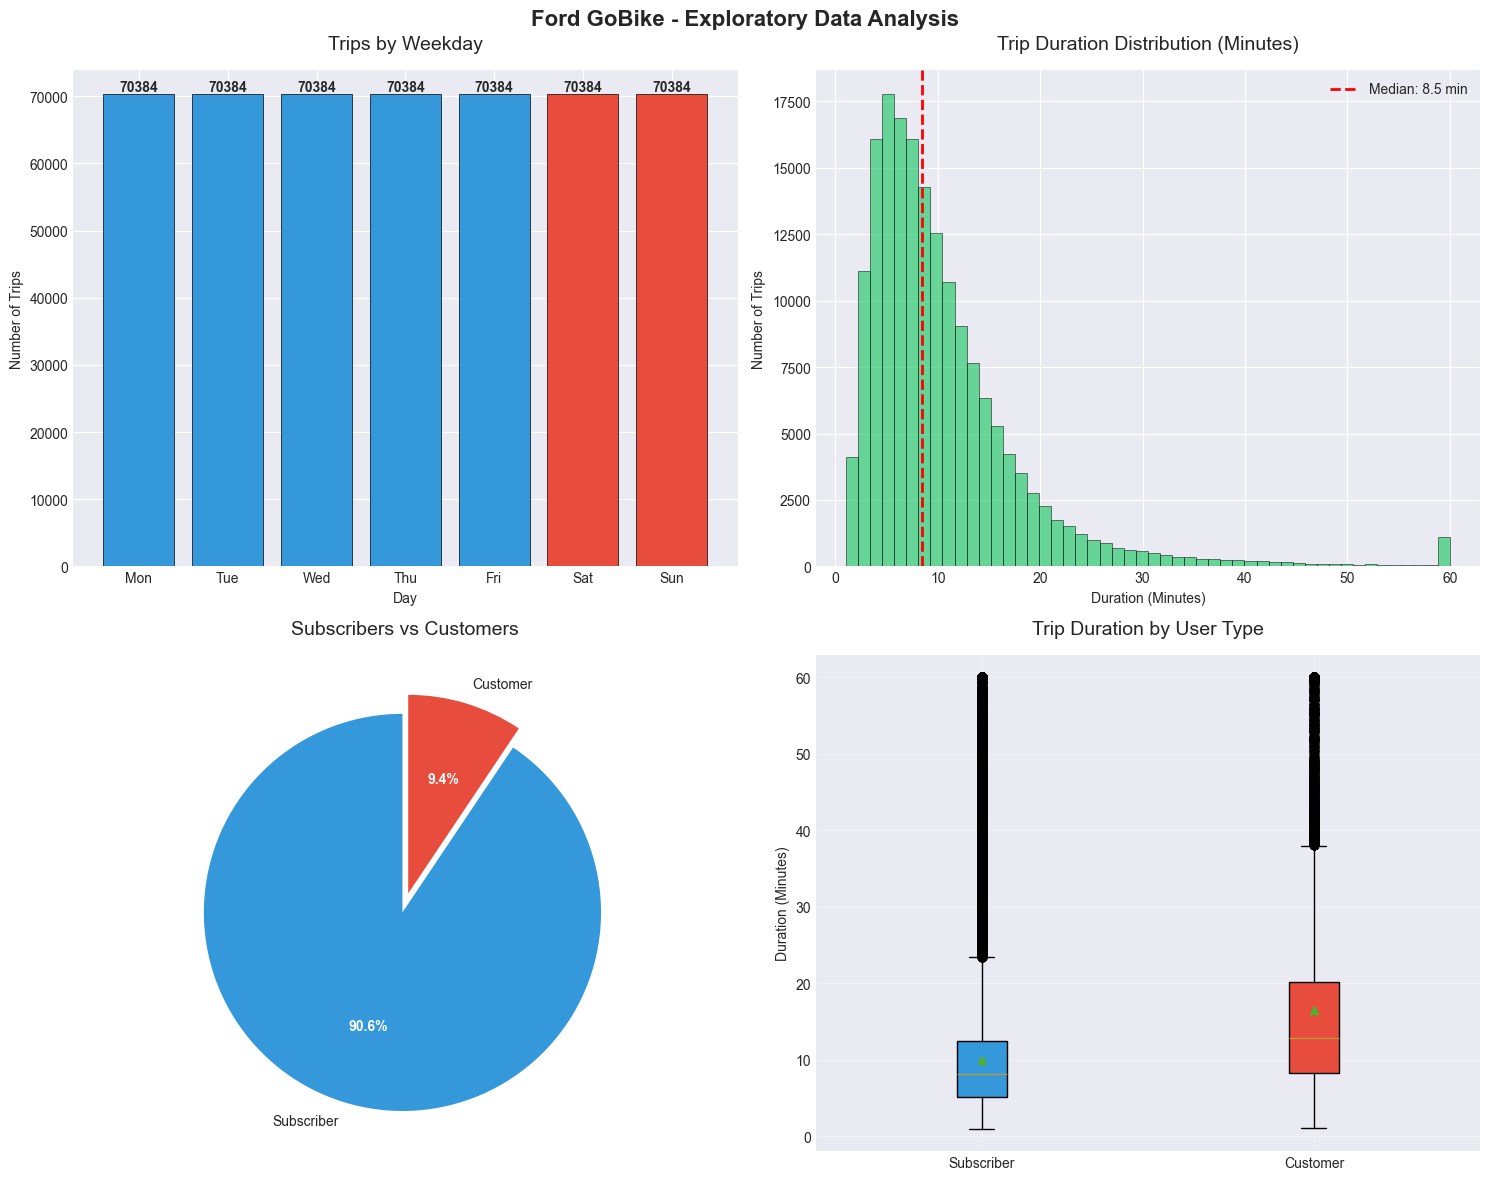


Quick Statistics:

1. Trips Summary:
   - Total Trips: 182,864
   - Average Duration: 10.82 min
   - Median Duration: 8.50 min
   - Longest Trip: 179.08 min
   - Shortest Trip: 1.02 min

2. User Distribution:
   - Subscriber: 158,017 (90.6%)
   - Customer: 16,402 (9.4%)

3. Weekend Analysis:
   - Weekend Trips: 70,384 (38.5%)
   - Weekday Trips: 112,480 (61.5%)

4. Top 5 Start Stations:
   1. Market St at 10th St...: 3,642 trips
   2. San Francisco Caltrain Station 2  (Townsend St at ...: 3,390 trips
   3. Berry St at 4th St...: 2,944 trips
   4. Montgomery St BART Station (Market St at 2nd St)...: 2,703 trips
   5. Powell St BART Station (Market St at 4th St)...: 2,611 trips


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Derived columns
df["duration_min"] = df["duration_sec"] / 60

# Convert start_time into datetime (using a fixed date since we only have time)
df["start_datetime"] = pd.to_datetime("2026-02-21 " + df["start_time"], errors="coerce")
df["start_dayofweek"] = df["start_datetime"].dt.dayofweek  # 0=Mon ... 6=Sun
df["is_weekend"] = df["start_dayofweek"].isin([5, 6])

# 2) Plot setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Ford GoBike - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 3) Trips by weekday
ax1 = axes[0, 0]
weekday_counts = df["start_dayofweek"].value_counts().sort_index()
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['#3498db' if i < 5 else '#e74c3c' for i in range(7)]

bars = ax1.bar(weekday_labels, weekday_counts.values, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Trips by Weekday', fontsize=14, pad=15)
ax1.set_xlabel('Day')
ax1.set_ylabel('Number of Trips')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

# 4) Trip duration distribution
ax2 = axes[0, 1]
duration_data = df["duration_min"].clip(upper=60)
ax2.hist(duration_data, bins=50, color='#2ecc71', edgecolor='black', linewidth=0.5, alpha=0.7)
ax2.set_title('Trip Duration Distribution (Minutes)', fontsize=14, pad=15)
ax2.set_xlabel('Duration (Minutes)')
ax2.set_ylabel('Number of Trips')
ax2.axvline(df["duration_min"].median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {df["duration_min"].median():.1f} min')
ax2.legend()

# 5) Subscriber vs Customer
ax3 = axes[1, 0]
user_counts = df["user_type"].value_counts()
colors_pie = ['#3498db', '#e74c3c']
wedges, texts, autotexts = ax3.pie(user_counts.values, labels=user_counts.index, autopct='%1.1f%%',
                                   colors=colors_pie, startangle=90, explode=(0.05, 0.05))
ax3.set_title('Subscribers vs Customers', fontsize=14, pad=15)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 6) Trip duration by user type
ax4 = axes[1, 1]
subscriber_data = df[df["user_type"] == "Subscriber"]["duration_min"].clip(upper=60)
customer_data = df[df["user_type"] == "Customer"]["duration_min"].clip(upper=60)
bp = ax4.boxplot([subscriber_data, customer_data], labels=["Subscriber", "Customer"],
                 patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax4.set_title('Trip Duration by User Type', fontsize=14, pad=15)
ax4.set_ylabel('Duration (Minutes)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7) Quick stats
print("\n" + "="*60)
print("Quick Statistics:")
print("="*60)
print(f"\n1. Trips Summary:")
print(f"   - Total Trips: {len(df):,}")
print(f"   - Average Duration: {df['duration_min'].mean():.2f} min")
print(f"   - Median Duration: {df['duration_min'].median():.2f} min")
print(f"   - Longest Trip: {df['duration_min'].max():.2f} min")
print(f"   - Shortest Trip: {df['duration_min'].min():.2f} min")

print(f"\n2. User Distribution:")
for user, count in df["user_type"].value_counts().items():
    pct = df["user_type"].value_counts(normalize=True)[user] * 100
    print(f"   - {user}: {count:,} ({pct:.1f}%)")

print(f"\n3. Weekend Analysis:")
print(f"   - Weekend Trips: {df['is_weekend'].sum():,} ({df['is_weekend'].mean()*100:.1f}%)")
print(f"   - Weekday Trips: {(~df['is_weekend']).sum():,} ({100 - df['is_weekend'].mean()*100:.1f}%)")

print(f"\n4. Top 5 Start Stations:")
top_stations = df["start_station_name"].value_counts().head(5)
for i, (station, count) in enumerate(top_stations.items(), 1):
    print(f"   {i}. {station[:50]}...: {count:,} trips")

PREPARING DATA FOR EDA...

Converting time columns to datetime...
Sample start_time values: ['54:18.5', '49:58.6', '55:35.1', '41:06.8', '41:48.8']
Successfully converted 174,419 out of 182,864 start times (95.4%)

Extracting time features...

✅ Data preparation complete. Final shape: (182864, 38)

DATA SUMMARY BEFORE PLOTTING:

Total rows: 182,864
Valid start_datetime: 174,419
Valid dayofweek: 174,419

Day of week distribution:
dayofweek
5.0    174419
Name: count, dtype: int64

CREATING VISUALIZATIONS...
  - Plotting weekday distribution...
  - Plotting duration distribution...
  - Plotting user type distribution...
  - Plotting duration by user type...


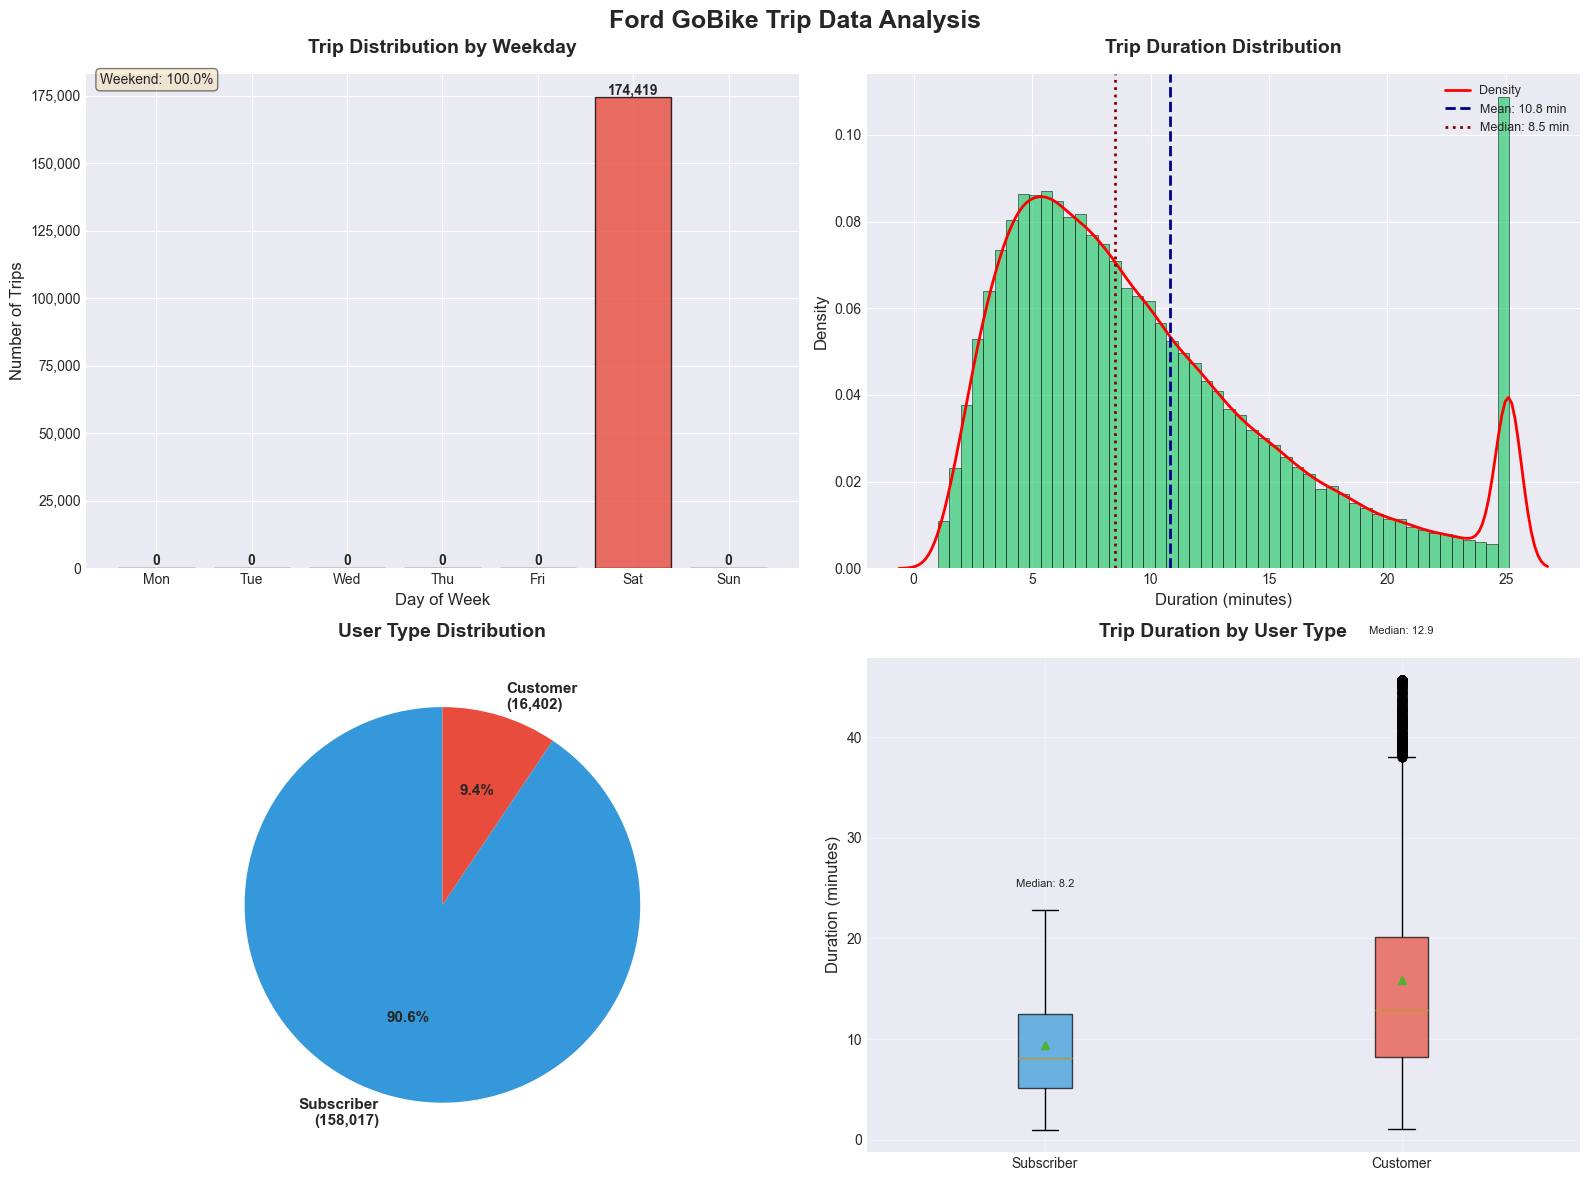


                              FORD GOBIKE - STATISTICAL SUMMARY

📊 OVERALL METRICS:
----------------------------------------
Total Trips:                      182,864

⏱️ DURATION STATISTICS (minutes):
----------------------------------------
Mean:                               10.82
Median:                              8.50
Std Dev:                            10.10
Min:                                 1.02
Max:                               179.08
95th Percentile:                    25.13

👥 USER TYPE ANALYSIS:
----------------------------------------

Subscriber:
  Count:             158,017 ( 86.4%)
  Avg Duration:        10.11 min
  Median Duration:       8.17 min

Customer:
  Count:              16,402 (  9.0%)
  Avg Duration:        17.68 min
  Median Duration:      12.90 min

nan:
  Count:                   0 (  0.0%)
  Avg Duration:          nan min
  Median Duration:        nan min

📅 WEEKEND ANALYSIS:
----------------------------------------
Weekend Trips:                   

In [52]:
"""
Ford GoBike - Exploratory Data Analysis (Professional Version)
==================================================================
A comprehensive EDA pipeline with best practices and advanced techniques
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. DATA PREPARATION & FEATURE ENGINEERING
# ============================================================
print("="*60)
print("PREPARING DATA FOR EDA...")
print("="*60)

# Make a copy to avoid warnings
df_eda = df.copy()

# 1.1 Basic duration feature
df_eda['duration_min'] = df_eda['duration_sec'] / 60

# 1.2 Fix datetime conversion - THIS IS THE KEY FIX
print("\nConverting time columns to datetime...")

# First, let's see what we're dealing with
print(f"Sample start_time values: {df_eda['start_time'].iloc[0:5].tolist()}")

# Since the time format appears to be "minutes:seconds.tenths" (e.g., "54:18.5")
# We need to parse it differently
def parse_time_string(time_str):
    """
    Parse time string in format "minutes:seconds.tenths"
    Returns a datetime object with a fixed date
    """
    try:
        if pd.isna(time_str):
            return pd.NaT
        
        # Split minutes and seconds
        minutes, seconds = str(time_str).split(':')
        minutes = int(minutes)
        
        # Handle seconds which might have decimal
        if '.' in seconds:
            seconds_part, ms_part = seconds.split('.')
            seconds_val = int(seconds_part)
            ms_val = int(ms_part) if ms_part.isdigit() else 0
        else:
            seconds_val = int(seconds)
            ms_val = 0
        
        # Create time string in HH:MM:SS format
        hours = minutes // 60
        remaining_minutes = minutes % 60
        
        # Format as HH:MM:SS.ms
        time_str_formatted = f"{hours:02d}:{remaining_minutes:02d}:{seconds_val:02d}.{ms_val:03d}"
        
        # Combine with a fixed date
        return pd.to_datetime(f"2026-02-21 {time_str_formatted}")
    except Exception as e:
        # If parsing fails, return NaT
        return pd.NaT

# Apply the parsing function
df_eda['start_datetime'] = df_eda['start_time'].apply(parse_time_string)
df_eda['end_datetime'] = df_eda['end_time'].apply(parse_time_string)

# Check if conversion worked
valid_starts = df_eda['start_datetime'].notna().sum()
print(f"Successfully converted {valid_starts:,} out of {len(df_eda):,} start times ({valid_starts/len(df_eda)*100:.1f}%)")

# 1.3 Extract time features
print("\nExtracting time features...")

# Extract features only from valid datetime values
mask_valid = df_eda['start_datetime'].notna()

if mask_valid.any():
    df_eda.loc[mask_valid, 'hour'] = df_eda.loc[mask_valid, 'start_datetime'].dt.hour
    df_eda.loc[mask_valid, 'dayofweek'] = df_eda.loc[mask_valid, 'start_datetime'].dt.dayofweek
    df_eda.loc[mask_valid, 'day_name'] = df_eda.loc[mask_valid, 'start_datetime'].dt.day_name()
    df_eda.loc[mask_valid, 'is_weekend'] = df_eda.loc[mask_valid, 'dayofweek'].isin([5, 6])
    
    # Time of day categorization
    df_eda.loc[mask_valid, 'time_of_day'] = pd.cut(
        df_eda.loc[mask_valid, 'hour'], 
        bins=[0, 6, 12, 18, 24], 
        labels=['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-18)', 'Evening (18-24)'],
        include_lowest=True, right=False
    )
else:
    print("WARNING: No valid datetime values found!")
    # Create default values
    df_eda['hour'] = 0
    df_eda['dayofweek'] = 0
    df_eda['day_name'] = 'Unknown'
    df_eda['is_weekend'] = False
    df_eda['time_of_day'] = 'Unknown'

# 1.4 Trip categorization
df_eda['trip_category'] = pd.cut(
    df_eda['duration_min'],
    bins=[0, 10, 30, 60, float('inf')],
    labels=['Short (<10min)', 'Medium (10-30min)', 
            'Long (30-60min)', 'Extra Long (>60min)']
)

# 1.5 Age features
current_year = 2026
df_eda['age'] = current_year - df_eda['member_birth_year']
df_eda['age_category'] = pd.cut(
    df_eda['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

print(f"\n✅ Data preparation complete. Final shape: {df_eda.shape}")

# ============================================================
# 2. CHECK DATA BEFORE PLOTTING
# ============================================================
print("\n" + "="*60)
print("DATA SUMMARY BEFORE PLOTTING:")
print("="*60)

print(f"\nTotal rows: {len(df_eda):,}")
print(f"Valid start_datetime: {df_eda['start_datetime'].notna().sum():,}")
print(f"Valid dayofweek: {df_eda['dayofweek'].notna().sum():,}")

if df_eda['dayofweek'].notna().any():
    print(f"\nDay of week distribution:")
    print(df_eda['dayofweek'].value_counts().sort_index())
else:
    print("\nWARNING: No dayofweek values available!")

# ============================================================
# 3. CREATE VISUALIZATIONS
# ============================================================
print("\n" + "="*60)
print("CREATING VISUALIZATIONS...")
print("="*60)

# Set up the plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Ford GoBike Trip Data Analysis', fontsize=18, fontweight='bold', y=0.98)

# Flatten axes for easier indexing
ax1, ax2, ax3, ax4 = axes.flatten()

# ============================================================
# 3.1 PLOT 1: Weekday Distribution
# ============================================================
print("  - Plotting weekday distribution...")

weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

if df_eda['dayofweek'].notna().any():
    weekday_counts = df_eda['dayofweek'].value_counts().sort_index()
    
    # Ensure we have all 7 days
    for i in range(7):
        if i not in weekday_counts.index:
            weekday_counts[i] = 0
    weekday_counts = weekday_counts.sort_index()
    
    colors = ['#3498db']*5 + ['#e74c3c']*2
    bars = ax1.bar(weekday_labels, weekday_counts.values, color=colors, 
                   edgecolor='black', linewidth=1, alpha=0.8)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}', ha='center', va='bottom', fontweight='bold')
    
    weekend_pct = (weekday_counts.loc[5:6].sum() / weekday_counts.sum() * 100) if weekday_counts.sum() > 0 else 0
    ax1.text(0.02, 0.98, f'Weekend: {weekend_pct:.1f}%', transform=ax1.transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
else:
    ax1.text(0.5, 0.5, 'No weekday data available', ha='center', va='center', transform=ax1.transAxes)

ax1.set_title('Trip Distribution by Weekday', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.set_ylabel('Number of Trips', fontsize=12)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

# ============================================================
# 3.2 PLOT 2: Duration Distribution
# ============================================================
print("  - Plotting duration distribution...")

duration_data = df_eda['duration_min'].dropna()
if len(duration_data) > 0:
    # Clip to 95th percentile for better visualization
    upper_limit = duration_data.quantile(0.95)
    duration_clipped = duration_data.clip(upper=upper_limit)
    
    ax2.hist(duration_clipped, bins=50, density=True, alpha=0.7, 
             color='#2ecc71', edgecolor='black', linewidth=0.5)
    
    # Add KDE
    sns.kdeplot(data=duration_clipped, ax=ax2, color='red', linewidth=2, label='Density')
    
    # Add statistics
    mean_dur = duration_data.mean()
    median_dur = duration_data.median()
    ax2.axvline(mean_dur, color='darkblue', linestyle='--', linewidth=2, 
                label=f'Mean: {mean_dur:.1f} min')
    ax2.axvline(median_dur, color='darkred', linestyle=':', linewidth=2, 
                label=f'Median: {median_dur:.1f} min')
    
    ax2.legend(loc='upper right', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'No duration data available', ha='center', va='center', transform=ax2.transAxes)

ax2.set_title('Trip Duration Distribution', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Duration (minutes)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)

# ============================================================
# 3.3 PLOT 3: User Type Distribution
# ============================================================
print("  - Plotting user type distribution...")

if 'user_type' in df_eda.columns and df_eda['user_type'].notna().any():
    user_counts = df_eda['user_type'].value_counts()
    colors_pie = ['#3498db', '#e74c3c'] if len(user_counts) >= 2 else ['#3498db']
    
    wedges, texts, autotexts = ax3.pie(
        user_counts.values, 
        labels=[f'{label}\n({count:,})' for label, count in zip(user_counts.index, user_counts.values)],
        autopct='%1.1f%%', colors=colors_pie, startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
else:
    ax3.text(0.5, 0.5, 'No user type data', ha='center', va='center', transform=ax3.transAxes)

ax3.set_title('User Type Distribution', fontsize=14, fontweight='bold', pad=15)

# ============================================================
# 3.4 PLOT 4: Duration by User Type (Box Plot)
# ============================================================
print("  - Plotting duration by user type...")

if 'user_type' in df_eda.columns and len(duration_data) > 0:
    user_types = df_eda['user_type'].unique()
    plot_data = []
    labels = []
    
    for user_type in user_types:
        user_data = df_eda[df_eda['user_type'] == user_type]['duration_min'].dropna()
        if len(user_data) > 0:
            # Clip to 95th percentile
            upper = user_data.quantile(0.95)
            plot_data.append(user_data.clip(upper=upper))
            labels.append(user_type)
    
    if plot_data:
        bp = ax4.boxplot(plot_data, labels=labels, patch_artist=True, showmeans=True)
        
        # Color boxes
        colors_box = ['#3498db', '#e74c3c'][:len(plot_data)]
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Add statistics text
        for i, data in enumerate(plot_data):
            median = data.median()
            mean = data.mean()
            ax4.text(i+1, data.quantile(0.95) * 1.1, 
                    f'Median: {median:.1f}', ha='center', fontsize=8)
    else:
        ax4.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax4.transAxes)
else:
    ax4.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax4.transAxes)

ax4.set_title('Trip Duration by User Type', fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('Duration (minutes)', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 4. COMPREHENSIVE STATISTICAL SUMMARY
# ============================================================
print("\n" + "="*80)
print(" "*30 + "FORD GOBIKE - STATISTICAL SUMMARY")
print("="*80)

# Section 1: Overall Statistics
print("\n📊 OVERALL METRICS:")
print("-" * 40)
print(f"{'Total Trips:':<25} {len(df_eda):>15,}")

# Section 2: Duration Statistics
print("\n⏱️ DURATION STATISTICS (minutes):")
print("-" * 40)
if len(duration_data) > 0:
    print(f"{'Mean:':<25} {duration_data.mean():>15.2f}")
    print(f"{'Median:':<25} {duration_data.median():>15.2f}")
    print(f"{'Std Dev:':<25} {duration_data.std():>15.2f}")
    print(f"{'Min:':<25} {duration_data.min():>15.2f}")
    print(f"{'Max:':<25} {duration_data.max():>15.2f}")
    print(f"{'95th Percentile:':<25} {duration_data.quantile(0.95):>15.2f}")

# Section 3: User Type Analysis
print("\n👥 USER TYPE ANALYSIS:")
print("-" * 40)
if 'user_type' in df_eda.columns:
    for user_type in df_eda['user_type'].unique():
        user_df = df_eda[df_eda['user_type'] == user_type]
        print(f"\n{user_type}:")
        print(f"  {'Count:':<15} {len(user_df):>10,} ({len(user_df)/len(df_eda)*100:>5.1f}%)")
        print(f"  {'Avg Duration:':<15} {user_df['duration_min'].mean():>10.2f} min")
        print(f"  {'Median Duration:':<15} {user_df['duration_min'].median():>10.2f} min")

# Section 4: Weekend Analysis
print("\n📅 WEEKEND ANALYSIS:")
print("-" * 40)
if df_eda['is_weekend'].notna().any():
    weekend_trips = df_eda['is_weekend'].sum()
    print(f"{'Weekend Trips:':<25} {weekend_trips:>15,} ({weekend_trips/len(df_eda)*100:>5.1f}%)")
    print(f"{'Weekday Trips:':<25} {(~df_eda['is_weekend']).sum():>15,} ({(~df_eda['is_weekend']).sum()/len(df_eda)*100:>5.1f}%)")

# Section 5: Age Demographics
print("\n👤 AGE DEMOGRAPHICS:")
print("-" * 40)
age_valid = df_eda['age'].dropna()
if len(age_valid) > 0:
    print(f"{'Average Age:':<25} {age_valid.mean():>15.1f} years")
    print(f"{'Median Age:':<25} {age_valid.median():>15.1f} years")
    print(f"{'Age Range:':<25} {age_valid.min():>15.0f} - {age_valid.max():>15.0f} years")

# Section 6: Gender Distribution
print("\n⚥ GENDER DISTRIBUTION:")
print("-" * 40)
if 'member_gender' in df_eda.columns:
    gender_counts = df_eda['member_gender'].value_counts()
    for gender, count in gender_counts.items():
        print(f"{gender:<25} {count:>10,} ({count/len(df_eda)*100:>5.1f}%)")

print("\n" + "="*80)
print("✅ EDA COMPLETED SUCCESSFULLY")
print("="*80)